In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import functools
from math import pi

import numpy as np
import matplotlib as mpl
from matplotlib.gridspec import GridSpec
import matplotlib.pyplot as plt
import xarray as xr

from fluxoniumcr import DATA_DIR
from fluxoniumcr.plotting.collision_heatmap import bin2d_maximum, make_colorbar, mycmap
from fluxoniumcr.qubits.fluxonium import Fluxonium


plt.style.use("fluxoniumcr.plotting.paper")

In [3]:
q0 = Fluxonium(
    EJ=4.0 * (2*pi),
    EC=1.2 * (2*pi),
    EL=0.4 * (2*pi),
    flux=0.5,
    cutoff=128,
    dim=4,
)

q0_evals = q0.eigenvalues

parent_path = (
    DATA_DIR
    /"control_spectator_collision"
    / f"EJ=4.00,EC=1.20,EL=0.40,deltap=0.8"
)
dataset1 = xr.load_dataset(parent_path/"01to02_harmonic=-3.hdf5")
dataset2 = xr.load_dataset(parent_path/"01to12_harmonic=-4.hdf5")
dataset3 = xr.load_dataset(parent_path/"11to02_harmonic=-4.hdf5")

dataset4 = xr.load_dataset(parent_path/"01to20_harmonic=-3.hdf5")
dataset5 = xr.load_dataset(parent_path/"11to20_harmonic=-2.hdf5")
dataset6 = xr.load_dataset(parent_path/"00to01_harmonic=-1.hdf5")
dataset7 = xr.load_dataset(parent_path/"00to01_harmonic=-3.hdf5")
dataset8 = xr.load_dataset(parent_path/"00to11_harmonic=-2.hdf5")
dataset9 = xr.load_dataset(parent_path/"10to01_harmonic=-2.hdf5")

/home/eugene/ownCloud - Eugene Huang@surfdrive.surf.nl/Projects/scalable-fluxonium-cr/python/.venv/lib/python3.10/site-packages/xarray/computation/apply_ufunc.py:821: RuntimeWarning: divide by zero encountered in log10
  result_data = func(*input_data)


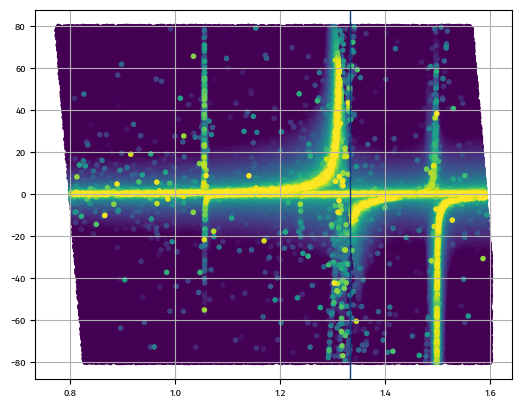

In [4]:
dataset = dataset1

ds = dataset.isel(JC=0)
leakage = ds.transition_probability.sel(spectator_bra=2).sum('control_bra').mean(['control_ket', 'spectator_ket'])

idx = np.argsort(leakage)

# idx = mask

plt.scatter(
    dataset.drive_frequency.sel(index=idx)/(2*pi),
    dataset.delta_frequency.sel(index=idx) * 1e3/(2*pi),
    c=np.log10(leakage.sel(index=idx)).data,
    vmin=-5,
    vmax=-1,
    s=9,
)

plt.grid()
# plt.xlim(-50, 50)
# plt.ylim(0.9, 1.5)
# plt.xlim(-15, 15)
# plt.ylim(0.7, 1.3)

plt.gca().set_aspect(1/250)

plt.axvline(1.332)

In [5]:
def calculate_error_contribution(dataset):
    attrs = dataset.attrs
    if attrs['control_final_state'] == attrs['control_initial_state']:
        assert attrs['spectator_final_state'] != attrs['spectator_initial_state']
        err = sum(
            dataset.transition_probability.sel(
                control_bra=i,
                control_ket=i,
                spectator_bra=attrs['spectator_final_state'],
                spectator_ket=attrs['spectator_initial_state'],
            )
            for i in range(2)
        )
        if attrs['spectator_final_state'] <= 1:
            err += sum(
                dataset.transition_probability.sel(
                    control_bra=i,
                    control_ket=i,
                    spectator_bra=attrs['spectator_initial_state'],
                    spectator_ket=attrs['spectator_final_state'],
                )
                for i in range(2)
            )
    elif attrs['control_final_state'] <= 1 and attrs['spectator_final_state'] <= 1:
        err = (
            dataset.transition_probability.sel(
                control_bra=attrs['control_final_state'],
                control_ket=attrs['control_initial_state'],
                spectator_bra=attrs['spectator_final_state'],
                spectator_ket=attrs['spectator_initial_state'],
            )
            + dataset.transition_probability.sel(
                control_bra=attrs['control_initial_state'],
                control_ket=attrs['control_final_state'],
                spectator_bra=attrs['spectator_initial_state'],
                spectator_ket=attrs['spectator_final_state'],
            )
        )
    else:
        err = dataset.transition_probability.sel(
            control_bra=attrs['control_final_state'],
            control_ket=attrs['control_initial_state'],
            spectator_bra=attrs['spectator_final_state'],
            spectator_ket=attrs['spectator_initial_state'],
        )
        
    if attrs['control_final_state'] <= 1 and attrs['spectator_final_state'] <= 1:
        err = 1/5 * err
    else:
        err = 1/4 * err
    
    return err

In [6]:
def plot_dataset(ax, cax, dataset, x_edges, y_edges, set_xlabel=True, ylabel_pad=None, clabel="Error contribution"):
    harmonic = dataset.attrs['harmonic']
    control_final_state = dataset.attrs['control_final_state']
    control_initial_state = dataset.attrs['control_initial_state']
    spectator_final_state = dataset.attrs['spectator_final_state']
    spectator_initial_state = dataset.attrs['spectator_initial_state']

    arr = calculate_error_contribution(dataset).isel(JC=0)

    bare_delta = (
        dataset.transition_frequency
        + q0_evals[control_final_state] - q0_evals[control_initial_state]
        + harmonic * dataset.drive_frequency
    )

    Z = bin2d_maximum(
        dataset.drive_frequency.data,
        bare_delta.data,
        arr.data,
        x_edges,
        y_edges,
    )

    norm = mpl.colors.LogNorm(vmin=1e-6/5, vmax=5e-2)
    ax.pcolormesh(
        x_edges,
        y_edges,
        Z,
        rasterized=True,
        cmap=mycmap,
        norm=norm,
    )

    make_colorbar(
        cax,
        norm,
        mycmap,
        vmin=1e-6,
        vmax=1e-2,
        yticks=np.array([1e-6, 1e-5, 1e-4, 1e-3, 1e-2]),
        label=clabel,
    )

    if set_xlabel:
        ax.set_xlabel(r"Drive frequency $\omega_\mathrm{d}/2\pi$  [GHz]")

    freq1 = (
        r"\omega_\mathrm{s}^{"
            + f"{spectator_final_state}{spectator_initial_state}"
        + "}"
    )

    if control_final_state != control_initial_state:
        i = max(control_final_state, control_initial_state)
        j = min(control_final_state, control_initial_state)
        if control_final_state > control_initial_state:
            sign = "+"
        else:
            sign = "-"

        freq2 = (
            sign
            + r"\omega_\mathrm{c}^{"
                + f"{i}{j}"
            + "}"
        )
    else:
        freq2 = ""

    if abs(harmonic) > 1:
        freq3 = str(harmonic) + "\omega_\mathrm{d}"
    else:
        freq3 = str(harmonic)[:-1] + "\omega_\mathrm{d}"

    ylabel = ("$" + 
        "("
            + freq1
            + freq2
            + freq3
        + r")/2\pi"
    + "$")

    ax.set_ylabel(ylabel, labelpad=ylabel_pad)

    ax.xaxis.set_major_formatter(lambda x, pos: f"{x/(2*pi):.1f}")
    ax.yaxis.set_major_formatter(lambda y, pos: f"{y*1e3/(2*pi):.0f}")
    ax.xaxis.set_major_locator(mpl.ticker.MultipleLocator(base=0.1 * 2*pi))
    ax.yaxis.set_major_locator(mpl.ticker.MultipleLocator(base=20e-3 * 2*pi))

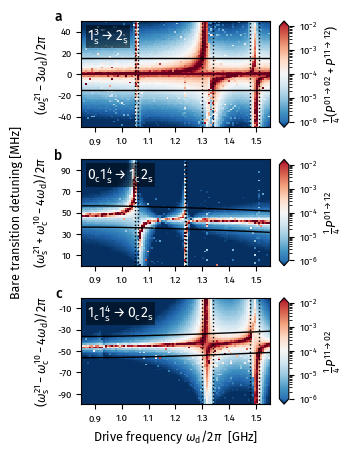

In [8]:
fig = plt.figure(
    figsize=(85/25.4, 110/25.4),
)

gs = GridSpec(
    nrows=3,
    ncols=2,
    figure=fig,
    width_ratios=[100, 5],
    hspace=0.3,
    wspace=0.1,
)

ax1 = fig.add_subplot(gs[0, 0])
cax1 = fig.add_subplot(gs[0, 1])
ax2 = fig.add_subplot(gs[1, 0])
cax2 = fig.add_subplot(gs[1, 1])
ax3 = fig.add_subplot(gs[2, 0])
cax3 = fig.add_subplot(gs[2, 1])

plot_dataset(
    ax1,
    cax1,
    dataset1,
    x_edges=np.linspace(0.85, 1.55, 96) * 2*pi,
    y_edges=np.linspace(-50e-3, 50e-3, 64) * 2*pi,
    set_xlabel=False,
    clabel=r"$\frac{1}{4}(P^{01\to02} + P^{11\to12})$"
)

plot_dataset(
    ax2,
    cax2,
    dataset2,
    x_edges=np.linspace(0.85, 1.55, 96) * 2*pi,
    y_edges=(50e-3 + np.linspace(-50e-3, 50e-3, 64)) * 2*pi,
    set_xlabel=False,
    ylabel_pad=7,
    clabel=r"$\frac{1}{4}P^{01\to12}$"
)

plot_dataset(
    ax3,
    cax3,
    dataset3,
    x_edges=np.linspace(0.85, 1.55, 96) * 2*pi,
    y_edges=(-50e-3 + np.linspace(-50e-3, 50e-3, 64)) * 2*pi,
    clabel=r"$\frac{1}{4}P^{11\to02}$"
)

ax2.set_yticks(
    (+50 + np.array([-40, -20, 0, 20, 40])) * 1e-3 * 2*pi,
)
ax3.set_yticks(
    (-50 + np.array([-40, -20, 0, 20, 40])) * 1e-3 * 2*pi,
)

c='black'

for ax in [ax1, ax2]:
    ax.axvline(1.050 * (2*pi), ls=':', c=c)
    ax.axvline(1.062 * (2*pi), ls=':', c=c)
    
ax.axvline(1.237 * 2*pi, ls=':', c=c)
ax.axvline(1.241 * 2*pi, ls=':', c=c)

for ax in [ax1, ax3]:
    ax.axvline(1.299 * 2*pi, ls=':', c=c)
    ax.axvline(1.338 * 2*pi, ls=':', c=c)
    ax.axvline(1.478 * 2*pi, ls=':', c=c)
    ax.axvline(1.510 * 2*pi, ls=':', c=c)

for sign in (1, -1):
    ax1.plot(
        np.array([0.85, 1.262, 1.262, 1.362, 1.362, 1.55]) * (2*pi),
        sign * np.array([15, 15, 15, 15, 15, 15]) * (1e-3 * 2*pi),
        c='black',
        solid_joinstyle='miter',
    )
    
bare_delta2 = (
    dataset2.transition_frequency
    + q0_evals[1] - q0_evals[0]
    - 4 * dataset2.drive_frequency
)
idx = np.argsort(dataset2.drive_frequency)[::600]
x = dataset2.drive_frequency.data[idx]
y = (bare_delta2.data - dataset2.delta_frequency.data)[idx]
i1 = np.searchsorted(x, (1.070 - 60e-3)*2*pi)
x = np.insert(x, i1, x[i1])
y = np.insert(y, i1, y[i1])
i2 = np.searchsorted(x, (1.070 - 0e-3)*2*pi)
x = np.insert(x, i2, x[i2])
y = np.insert(y, i2, y[i2])
offset = np.full(len(y), 10e-3 * 2*pi)
# offset[i1+1:i2+1] = 20e-3 * 2*pi
ax2.plot(x, y + offset, c='black')
ax2.plot(x, y - offset, c='black')
    
bare_delta3 = (
    dataset3.transition_frequency
    + q0_evals[0] - q0_evals[1]
    - 4 * dataset3.drive_frequency
)
idx = np.argsort(dataset3.drive_frequency)[::600]
x = dataset3.drive_frequency.data[idx]
y = (bare_delta3.data - dataset3.delta_frequency.data)[idx]
offset = np.full(len(y), 10e-3 * 2*pi)
ax3.plot(x, y + offset, c='black')
ax3.plot(x, y - offset, c='black')
    
for ax, label in [(ax1, "a"), (ax2, "b"), (ax3, "c")]:
    annotation = ax.annotate(
        label,
        (0.00, 1.00),
        (-14, 8),
        xycoords='axes fraction',
        textcoords='offset points',
        fontweight='medium',
        fontsize=10,
        ha="right",
        va="top",
        zorder=1,
    )
    
for ax in [ax1, ax2, ax3]:
    ax.set_xlim(0.85 * 2*pi, 1.55 * 2*pi)
    
    
for ax, label in [
        (ax1, r"$1_\mathrm{s}^3\to 2_\mathrm{s}$"),
        (ax2, r"$0_\mathrm{c}1_\mathrm{s}^4\to1_\mathrm{c}2_\mathrm{s}$"),
        (ax3, r"$1_\mathrm{c}1_\mathrm{s}^4\to0_\mathrm{c}2_\mathrm{s}$"),
]:
    annotation = ax.annotate(
        label,
        (0.00, 1.00),
        (4, -4),
        xycoords='axes fraction',
        textcoords='offset points',
        fontweight='medium',
        fontsize=10,
        ha="left",
        va="top",
        c='white',
        zorder=2,
        bbox=dict(boxstyle='square,pad=0.1', fc='black', ec='none', alpha=0.5)
    )
    

ax2.annotate(
    "Bare transition detuning [MHz]",
    (0, 0.5),
    (-42, 0),
    xycoords='axes fraction',
    textcoords='offset points',
    fontsize=plt.rcParams['axes.labelsize'],
    va='center',
    ha='right',
    rotation=90,
)
fig.subplots_adjust(
    left=0.23,
    right=0.85,
    bottom=0.09,
    top=0.975,
)


# ax1.set_facecolor('lime')
# ax2.set_facecolor('lime')
# ax3.set_facecolor('lime')
fig.savefig("spectator_leakage_all.pdf")

In [9]:
from matplotlib.colors import LinearSegmentedColormap

myblues = LinearSegmentedColormap.from_list(
    "myblues",
    [
        "#f7fbff",
        "#deebf7",
        "#c6dbef",
        "#9ecae1",
        "#6baed6",
        "#4292c6",
        "#2171b5",
        "#08519c",
        "#08306b",
    ]
)

myoranges = LinearSegmentedColormap.from_list(
    "myoranges",
    ['#fff5eb','#fee6ce','#fdd0a2','#fdae6b','#fd8d3c','#f16913','#d94801','#a63603','#7f2704'],
)

myblues.set_bad('lightgray')

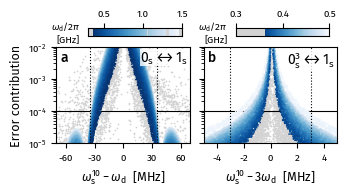

In [10]:
fig = plt.figure(
    figsize=(85/25.4, 45/25.4),
)


gs = GridSpec(
    nrows=2,
    ncols=2,
    figure=fig,
    width_ratios=[1, 1],
    height_ratios=[8, 92],
    hspace=0.2,
    wspace=0.1,
)
ax1 = fig.add_subplot(gs[1, 0])
ax2 = fig.add_subplot(gs[1, 1])
cax1 = fig.add_subplot(gs[0, 0])
cax2 = fig.add_subplot(gs[0, 1])

ax2.tick_params(labelleft=False)

def plot_spectator_bitflip_dataset(
        ax,
        dataset,
        norm,
        cmap,
        subfig_label,
        transition_label,
        cax,
):  
    # Cap drive frequency to 1.5 GHz
    dataset = dataset.sel(index=dataset.drive_frequency < 1.5 * 2*pi)
    if (
            dataset.attrs['spectator_final_state'] <= 1
    ):
        # Cap spectator qubit frequency to 1.5 GHz
        dataset = dataset.sel(index=abs(dataset.transition_frequency) < 1.5 * 2*pi)

    drive_frequency = dataset.drive_frequency
    mask_idx = (
        (
            (drive_frequency > 0.362 * 2*pi)
        )
        & ~(
            (drive_frequency > 1.050 * 2*pi)
            & (drive_frequency < 1.062 * 2*pi)
        )
        & ~(
            (drive_frequency > 1.237 * 2*pi)
            & (drive_frequency < 1.241 * 2*pi)
        )
        & ~(
            (drive_frequency > 1.299 * 2*pi)
            & (drive_frequency < 1.337 * 2*pi)
        )
        & ~(
            (drive_frequency > 1.466 * 2*pi)
            & (drive_frequency < 1.510 * 2*pi)
        )
    )


    z = dataset.drive_frequency.sel(index=mask_idx)
    sort_idx = z.index[np.argsort(-z.data)]

    ax.scatter(
        dataset.delta_frequency.sel(index=sort_idx).data,
        calculate_error_contribution(dataset.sel(index=sort_idx)).isel(JC=0).data,
        c=z.sel(index=sort_idx)/(2*pi),
        cmap=cmap,
        norm=norm,
        s=6,
        marker='.',
        linewidth=0,
        rasterized=True,
    )
    ax.scatter(
        dataset.delta_frequency.sel(index=~mask_idx).data,
        calculate_error_contribution(dataset.sel(index=~mask_idx)).isel(JC=0).data,
        color=cmap.get_bad(),
        s=6,
        marker='.',
        linewidth=0,
        rasterized=True,
        zorder=-10,
    )

    ax.set_yscale('log')
    ax.set_ylim(1e-5, 1e-2)
    ax.xaxis.set_major_formatter(lambda x, pos: f"{x*1e3/(2*pi):.0f}")
    
    ax.axhline(
        1e-4,
#         c=plt.rcParams['grid.color'],
        c='black',
        lw=plt.rcParams['grid.linewidth'],
        zorder=-1,
    )
    
    ax.annotate(
        subfig_label,
        (0.00, 1.00),
        (3, -2),
        xycoords='axes fraction',
        textcoords='offset points',
        fontweight='medium',
        fontsize=10,
        ha="left",
        va="top",
        zorder=1,
    )
    
    ax.annotate(
        transition_label,
        (1.00, 1.00),
        (-2, -2),
        xycoords='axes fraction',
        textcoords='offset points',
        fontsize=10,
        ha="right",
        va="top",
        c='black',
        zorder=3,
        bbox=dict(boxstyle='square,pad=0.0', fc='white', ec='none', alpha=0.8)
    )
    stops = np.linspace(
        dataset.drive_frequency.data.min() - 50e-3 * 2*pi,
        dataset.drive_frequency.data.max() + 50e-3 * 2*pi,
        256,
    )
    gradient_extent_xmin = stops.min()/(2*pi)
    gradient_extent_xmax = stops.max()/(2*pi)
    
    stops [
        (
            (stops < 0.362 * 2*pi)
        )
        | (
            (stops > 1.050 * 2*pi)
            & (stops < 1.062 * 2*pi)
        )
        | (
            (stops > 1.237 * 2*pi)
            & (stops < 1.241 * 2*pi)
        )
        | (
            (stops > 1.299 * 2*pi)
            & (stops < 1.337 * 2*pi)
        )
        | (
            (stops > 1.466 * 2*pi)
            & (stops < 1.510 * 2*pi)
        )
    ] = np.nan
    
    gradient = cax.imshow(
        cmap(norm(stops/(2*np.pi)))[None, :],
        aspect='auto',
        extent=(
            gradient_extent_xmin,
            gradient_extent_xmax,
            0,
            1,
        ),
        origin='lower',
        interpolation='none',
    )
    cax.set_xlim(z.data.min()/(2*np.pi), z.data.max()/(2*np.pi))
    
    cax.tick_params(
        labelbottom=False,
        bottom=False,
        labeltop=True,
        top=True,
        left=False,
        labelleft=False,
    )
    cax.xaxis.set_label_position('top')
    cax.annotate(
        r"$\omega_\mathrm{d}/2\pi$""\n[GHz]",
        (0.0, 0.5),
        (-6, 0),
        xycoords='axes fraction',
        textcoords='offset points',
        fontsize=plt.rcParams['xtick.labelsize'],
        ha='right',
        va='center',
    )
    cax.set_anchor((0.8, 0.5))
    

norm1 = mpl.colors.Normalize(
    vmin=0.35,
    vmax=1.5,
)
cmap1 = myblues.reversed()
plot_spectator_bitflip_dataset(
    ax1,
    dataset6,
    norm=norm1,
    cmap=cmap1,
    subfig_label="a",
    transition_label=r"$0_\mathrm{s} \leftrightarrow 1_\mathrm{s}$",
    cax=cax1,
)

norm2 = mpl.colors.Normalize(
    vmin=0.35,
    vmax=0.5,
)
cmap2 = myblues.reversed()
plot_spectator_bitflip_dataset(
    ax2,
    dataset7,
    norm=norm2,
    cmap=cmap2,
    subfig_label="b",
    transition_label=r"$0_\mathrm{s}^3 \leftrightarrow 1_\mathrm{s}$",
    cax=cax2,
)

for ax, x in [
    (ax1, -35e-3 * 2*pi),
    (ax1, +35e-3 * 2*pi),
    (ax2, -3e-3 * 2*pi),
    (ax2, +3e-3 * 2*pi),
]:
    ax.axvline(
        x,
#         c=plt.rcParams['grid.color'],
        c='black',
        lw=plt.rcParams['grid.linewidth'],
        ls=':',
    )

ax1.set_xlim(-0.07 * 2*pi, 0.07 * 2*pi)
ax1.set_xticks(np.array([-60, -30, 0, 30, 60]) * 1e-3 * 2*pi)
ax2.set_xlim(-5e-3 * 2*pi, 5e-3 * 2*pi)
ax2.set_xticks(np.array([-4, -2, 0, 2, 4]) * 1e-3 * 2*pi)

ax1.set_xlabel(
    r"$\omega_\mathrm{s}^{10} - \omega_\mathrm{d}$  [MHz]"
)
ax2.set_xlabel(
    r"$\omega_\mathrm{s}^{10} - 3\omega_\mathrm{d}$  [MHz]"
)

ax1.set_ylabel("Error contribution")
cax1.set_xticks(
    [0.5, 1.0, 1.5]
)
cax2.set_xticks(
    [0.3, 0.4, 0.5]
)
cax1.set_xlim(0.3, 1.5)
cax2.set_xlim(0.3, 0.5)
    
cax1.set_aspect(1/28 * 1.2/0.4)
cax2.set_aspect(1/28 * 0.2/0.4)
    
fig.subplots_adjust(
    left=0.14,
    right=0.98,
    bottom=0.23,
    top=0.88,
)

fig.savefig("spectator_bitflip.pdf", dpi=600)

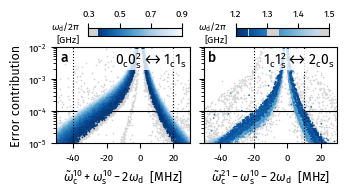

In [11]:
fig = plt.figure(
    figsize=(85/25.4, 45/25.4),
)


gs = GridSpec(
    nrows=2,
    ncols=2,
    figure=fig,
    width_ratios=[1, 1],
    height_ratios=[8, 92],
    hspace=0.2,
    wspace=0.1,
)
ax1 = fig.add_subplot(gs[1, 0])
ax2 = fig.add_subplot(gs[1, 1])
cax1 = fig.add_subplot(gs[0, 0])
cax2 = fig.add_subplot(gs[0, 1])

ax2.tick_params(labelleft=False)

norm1 = mpl.colors.Normalize(
    vmin=0.35,
    vmax=0.9,
)
cmap1 = myblues.reversed()
plot_spectator_bitflip_dataset(
    ax1,
    dataset8,
    norm=norm1,
    cmap=cmap1,
    subfig_label="a",
    transition_label=r"$0_\mathrm{c}0_\mathrm{s}^2 \leftrightarrow 1_\mathrm{c}1_\mathrm{s}$",
    cax=cax1,
)
ax1.set_xlim(-0.05 * 2*pi, 0.030 * 2*pi)
ax1.set_xticks(np.array([-40, -20, 0, 20]) * 1e-3 * 2*pi)
ax1.set_xlabel(
    r"$\tilde\omega_\mathrm{c}^{10} + \omega_\mathrm{s}^{10} - 2\omega_\mathrm{d}$  [MHz]"
)

norm2 = mpl.colors.Normalize(
    vmin=1.2,
    vmax=1.55,
)
cmap2 = myblues.reversed()
plot_spectator_bitflip_dataset(
    ax2,
    dataset5,
    norm=norm2,
    cmap=cmap2,
    subfig_label="b",
    transition_label=r"$1_\mathrm{c}1_\mathrm{s}^2 \leftrightarrow 2_\mathrm{c}0_\mathrm{s}$",
    cax=cax2,
)
ax2.set_xlim(-0.05 * 2*pi, 0.03 * 2*pi)
ax2.set_xticks(np.array([-40, -20, 0, 20]) * 1e-3 * 2*pi)
ax2.set_xlabel(
    r"$\tilde\omega_\mathrm{c}^{21} - \omega_\mathrm{s}^{10} - 2\omega_\mathrm{d}$  [MHz]"
)

for ax, x in [
    (ax1, -40e-3 * 2*pi),
    (ax1, +20e-3 * 2*pi),
    (ax2, -20e-3 * 2*pi),
    (ax2, +10e-3 * 2*pi),
]:
    ax.axvline(
        x,
#         c=plt.rcParams['grid.color'],
        c='black',
        lw=plt.rcParams['grid.linewidth'],
        ls=':',
    )
    
cax1.set_xticks(
    [0.3, 0.5, 0.7, 0.9]
)
cax2.set_xticks(
    [1.2, 1.3, 1.4, 1.5]
)
cax1.set_xlim(0.3, 0.9)
cax2.set_xlim(1.2, 1.5)
cax1.set_aspect(1/28 * 0.6/0.4)
cax2.set_aspect(1/28 * 0.3/0.4)

ax1.set_ylabel("Error contribution")

fig.subplots_adjust(
    left=0.14,
    right=0.98,
    bottom=0.23,
    top=0.88,
)

fig.savefig("control_and_spectator_primary.pdf", dpi=600)

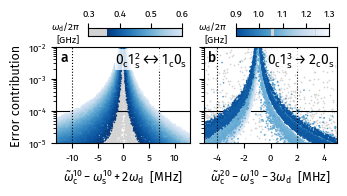

In [12]:
fig = plt.figure(
    figsize=(85/25.4, 45/25.4),
)


gs = GridSpec(
    nrows=2,
    ncols=2,
    figure=fig,
    width_ratios=[1, 1],
    height_ratios=[8, 92],
    hspace=0.2,
    wspace=0.1,
)
ax1 = fig.add_subplot(gs[1, 0])
ax2 = fig.add_subplot(gs[1, 1])
cax1 = fig.add_subplot(gs[0, 0])
cax2 = fig.add_subplot(gs[0, 1])

ax2.tick_params(labelleft=False)

norm1 = mpl.colors.Normalize(
    vmin=0.35,
    vmax=0.65,
)
cmap1 = myblues.reversed()
ds9_copy = dataset9.copy(deep=True)
ds9_copy['delta_frequency'] *= -1
plot_spectator_bitflip_dataset(
    ax1,
    ds9_copy,
    norm=norm1,
    cmap=cmap1,
    subfig_label="a",
    transition_label=r"$0_\mathrm{c}1_\mathrm{s}^2 \leftrightarrow 1_\mathrm{c}0_\mathrm{s}$",
    cax=cax1,
)
ax1.set_xlim(-0.013 * 2*pi, 0.013 * 2*pi)
ax1.set_xticks(np.array([-10, -5, 0, 5, 10]) * 1e-3 * 2*pi)
ax1.set_xlabel(
    r"$\tilde\omega_\mathrm{c}^{10} - \omega_\mathrm{s}^{10} + 2\omega_\mathrm{d}$  [MHz]"
)

norm2 = mpl.colors.Normalize(
    vmin=0.85,
    vmax=1.3,
)
cmap2 = myblues.reversed()
plot_spectator_bitflip_dataset(
    ax2,
    dataset4,
    norm=norm2,
    cmap=cmap2,
    subfig_label="b",
    transition_label=r"$0_\mathrm{c}1_\mathrm{s}^3 \to 2_\mathrm{c}0_\mathrm{s}$",
    cax=cax2,
)
ax2.set_xlim(-0.005 * 2*pi, 0.005 * 2*pi)
ax2.set_xticks(np.array([-4, -2, 0, 2, 4]) * 1e-3 * 2*pi)
ax2.set_xlabel(
    r"$\tilde\omega_\mathrm{c}^{20} - \omega_\mathrm{s}^{10} - 3\omega_\mathrm{d}$  [MHz]"
)

for ax, x in [
    (ax1, -10e-3 * 2*pi),
    (ax1, +7e-3 * 2*pi),
    (ax2, -4e-3 * 2*pi),
    (ax2, +2e-3 * 2*pi),
]:
    ax.axvline(
        x,
#         c=plt.rcParams['grid.color'],
        c='black',
        lw=plt.rcParams['grid.linewidth'],
        ls=':',
    )
    
cax1.set_xticks(
    [0.3, 0.4, 0.5, 0.6]
)
cax2.set_xticks(
    [0.9, 1.0, 1.1, 1.2, 1.3],
)
cax1.set_xlim(0.3, 0.6)
cax2.set_xlim(0.9, 1.3)
cax1.set_aspect(1/28 * 0.3/0.4)
cax2.set_aspect(1/28 * 0.4/0.4)

ax1.set_ylabel("Error contribution")

fig.subplots_adjust(
    left=0.14,
    right=0.98,
    bottom=0.23,
    top=0.88,
)

fig.savefig("control_and_spectator_secondary.pdf", dpi=600)